## Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../0-Dataset/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


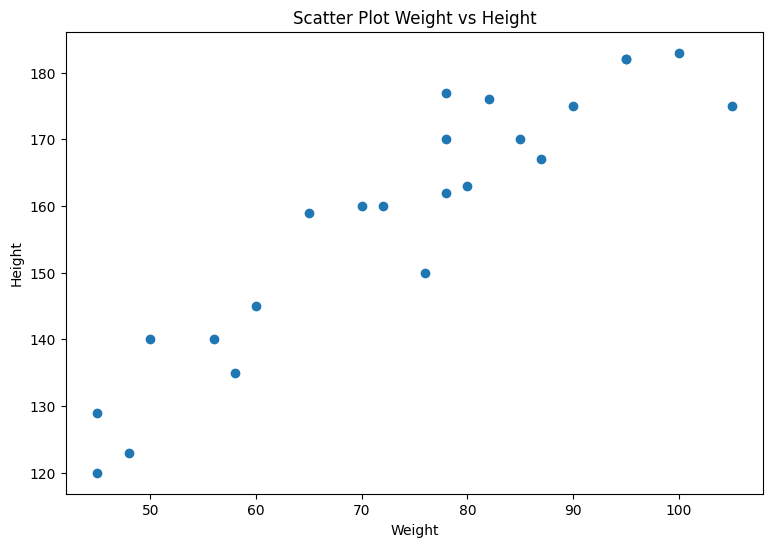

In [3]:
## Scatter Plot
plt.figure(figsize=(9,6))
plt.title('Scatter Plot Weight vs Height')
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()
plt.close()

In [4]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


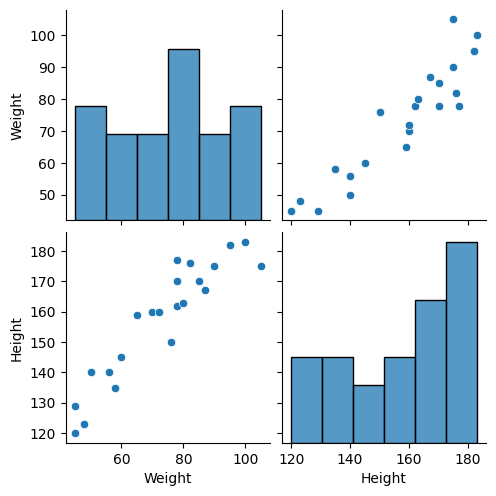

In [5]:
## Seaborn visualization
sns.pairplot(df)

In [6]:
## Independent and Dependent features

X = df[['Weight']] ## independent features should be data frame of 2 dimensional array
y = df['Height']  ## This variable is in series form or 1 D array

In [7]:
## Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [8]:
X.shape, y.shape, X_test.shape, X_train.shape, y_test.shape, y_train.shape

((23, 1), (23,), (6, 1), (17, 1), (6,), (17,))

In [9]:
## Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


##### Important things about the fit_transform and transform
- Why we use the fit_transform with the training dataset and transform with the test dataset?

- Using the fit_transform with the training dataset it using the Z-score to transform the values where the **mean of the X_train dataset is 0 and the standard deviation of the X_test data is 1**

- When we are going to use our X_test then in this case we are using the **transform** method in place of **fit_transform** because we are using the same value of mean and standard deviation which is calculated in the X_train values it is prevent the data leak.

- If we use the **fit_transform** in X_test dataset then we have give the information of our data in the testing phase and we are not wanted these things in case of testing the data

In [10]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

## Apply Simple Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
regression = LinearRegression()

In [14]:
regression.fit(X_train, y_train)

LinearRegression()

In [15]:
print("Coefficient or Slope:", regression.coef_)
print("Intercept:", regression.intercept_)

## Here slope means if you move the one unit in X axis the movement in Y axis is 17.29 units

## Intercept means if your x value is 0 then the value of y is 156.47


Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


#### Plot training data and best fit line

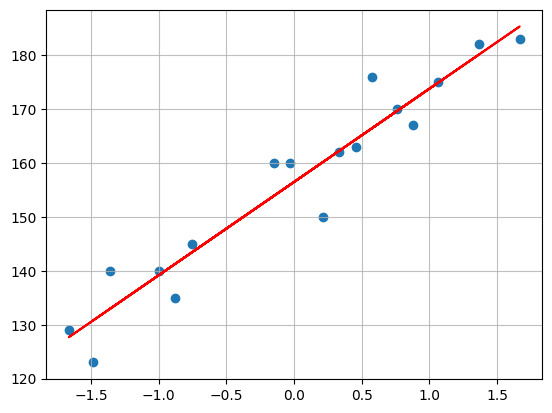

In [16]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = 'red')
plt.grid(True, alpha=0.8)

#### Prediction for test data
1. prediction height output = intercept + coef_(Weight)
2. y_pred_test = 156.740 + 17.29(X_test)

In [17]:
y_pred= regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

#### Performance matrics

In [18]:
from sklearn.metrics  import r2_score

In [19]:
score = r2_score(y_test, y_pred)
score

0.7360826717981276

#### OLS Linear Regression

In [20]:
# !pip install statsmodels

In [21]:
import statsmodels.api as sm

In [22]:
model = sm.OLS(y_train, X_train).fit()

In [23]:
prediction= model.predict(X_test)

In [24]:
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [25]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 22 Jul 2025   Prob (F-statistic):                       0.664
Time:                        00:18:15   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [26]:
## new data prediction

regression.predict([[72]]) ## the output you got is if the person having 72kg then it's height is 1401 cm, that is a wrong input because we miss a important step
## we have to standardized the number because we train our model on the Standard values so lets fix it 

array([1401.94139895])

In [27]:
regression.predict(scaler.transform([[72]])) ## this gives you the write ans

array([155.97744705])

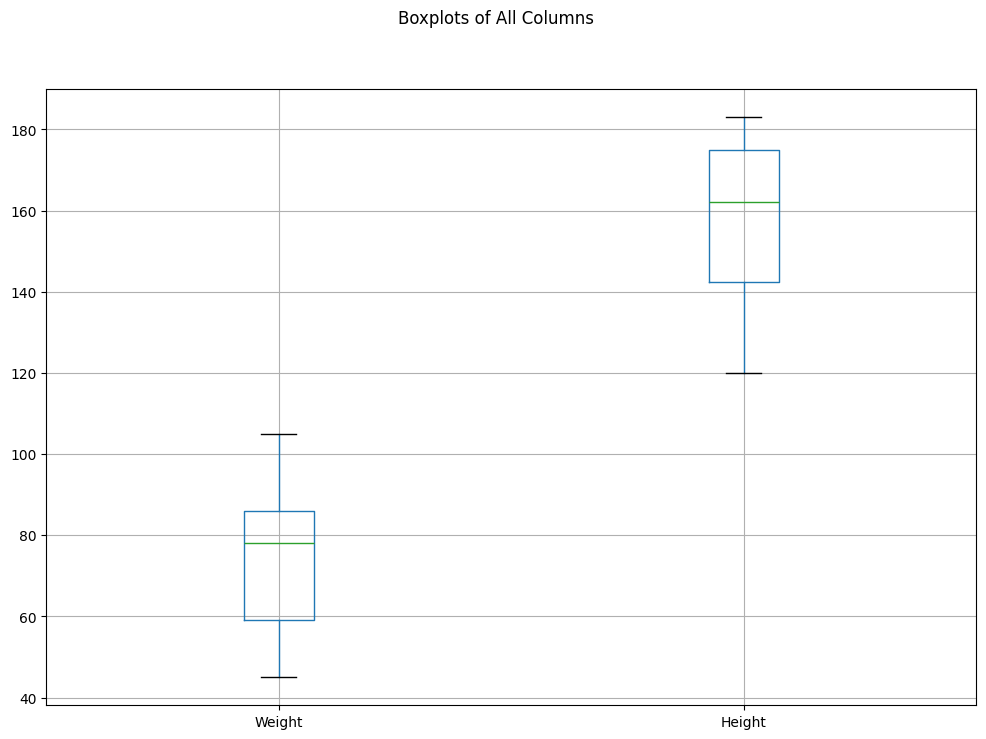

In [28]:
df.boxplot(figsize=(12, 8))
plt.suptitle('Boxplots of All Columns')
plt.show()

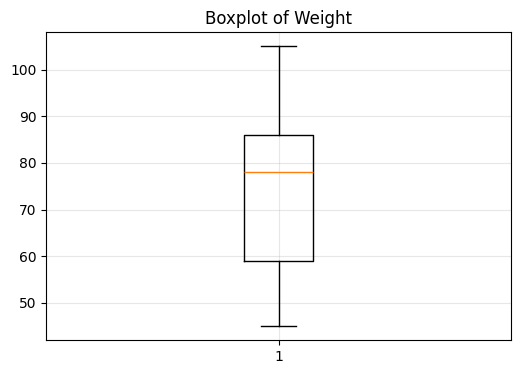

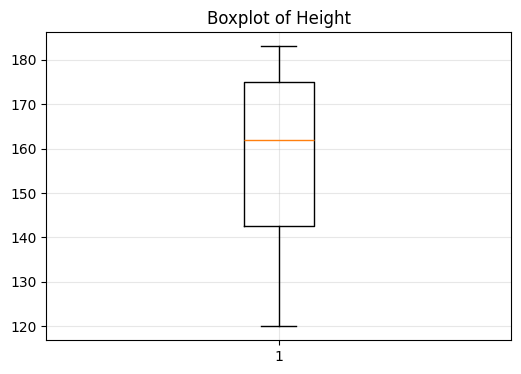

In [29]:
for col in df.columns:
    plt.figure(figsize=(6, 4))
    plt.title(f"Boxplot of {col}")
    plt.boxplot(df[col])
    plt.grid(True, alpha=0.3)
    plt.show()